# Gabarito — Classificação e Operações com Funções

Este notebook traz a resolução comentada dos exercícios de [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Funções e imports auxiliares definidos no notebook principal, necessários
# para os exercícios abaixo.
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_DESTAQUE = "#A3BE8C"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrao a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)


def temperatura(x):
    '''Temperatura (C) ao longo de um dia, de x=0 (6h) a x=14 (20h).'''
    x = np.asarray(x, dtype=float)
    return np.where(
        x < 4, 15 + 2 * x,
        np.where(x < 8, 23, 23 - 1.5 * (x - 8)),
    )


def eh_par(f, amostras=(1, 2, 3, 5)) -> bool:
    '''Verifica numericamente se f(-x) = f(x) para um conjunto de amostras de x.'''
    return all(np.isclose(f(-a), f(a)) for a in amostras)


def eh_impar(f, amostras=(1, 2, 3, 5)) -> bool:
    '''Verifica numericamente se f(-x) = -f(x) para um conjunto de amostras de x.'''
    return all(np.isclose(f(-a), -f(a)) for a in amostras)


def classificar_paridade(f) -> str:
    '''Classifica f como "par", "impar" ou "nenhuma", usando eh_par/eh_impar.'''
    if eh_par(f):
        return "par"
    if eh_impar(f):
        return "impar"
    return "nenhuma"


def funcao_nem_par_nem_impar(x):
    return x**2 + x


x_sym, y_sym = sp.symbols("x y")

## Básico

**Exercício 1.** Observando o gráfico de temperatura(x), em que intervalo a função é crescente? E decrescente?

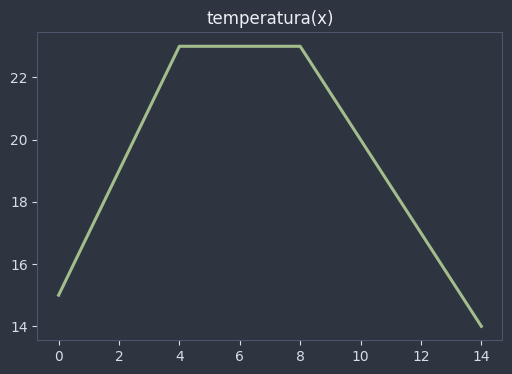

(0, 4) (8, 14)


In [2]:
xs_temp = np.linspace(0, 14, 400)
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs_temp, temperatura(xs_temp), color=COR_DESTAQUE, linewidth=2.2)
ax.set_title("temperatura(x)", color=NORD_TEXTO)
plt.show()

# o gráfico sobe de x=0 até x=4 (15°C -> 23°C), fica constante de x=4 até
# x=8 (patamar em 23°C) e cai de x=8 até x=14 (23°C -> 14°C)
intervalo_crescente_ex = (0, 4)
intervalo_decrescente_ex = (8, 14)

print(intervalo_crescente_ex, intervalo_decrescente_ex)

**Exercício 2.** Classifique h1(x)=x², h2(x)=x³ e x²+x (`funcao_nem_par_nem_impar`) em par, ímpar ou nenhuma das duas.

In [2]:
def h1(x):
    return x**2


def h2(x):
    return x**3


# h1(x) = x²: só tem potência par -> par
classificacao_h1 = classificar_paridade(h1)
# h2(x) = x³: só tem potência ímpar -> ímpar
classificacao_h2 = classificar_paridade(h2)
# x²+x mistura potência par (x²) e ímpar (x) -> nenhuma das duas
classificacao_h3 = classificar_paridade(funcao_nem_par_nem_impar)

print(classificacao_h1, classificacao_h2, classificacao_h3)

par impar nenhuma


## Intermediário

**Exercício 1.** Aplique o teste da reta horizontal nos quatro gráficos e classifique cada função como (injetora, sobrejetora), contradomínio declarado = R.

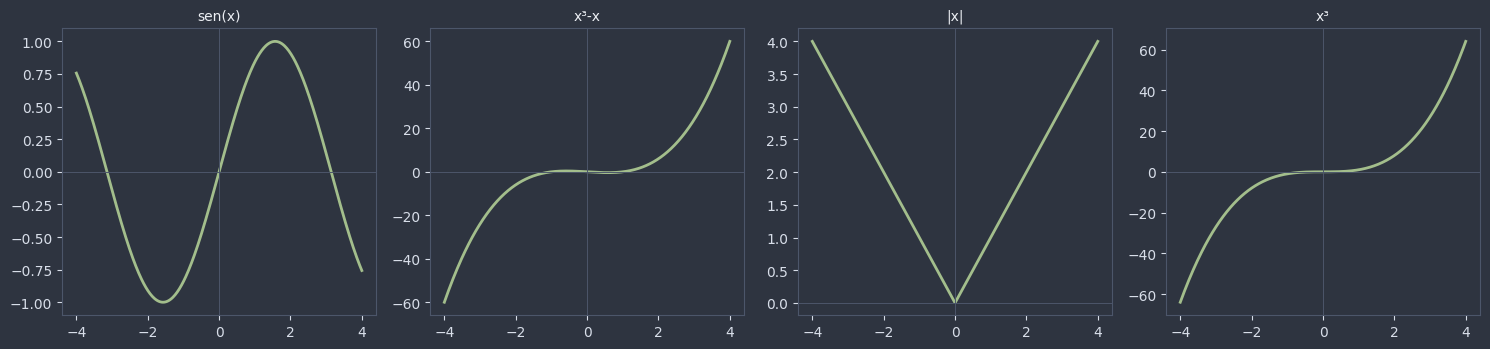

(False, False) (False, True) (False, False) (True, True)


In [3]:
def p1(x):
    return np.sin(x)


def p2(x):
    return x**3 - x


def p3(x):
    return np.abs(x)


def p4(x):
    return x**3


xs_int1 = np.linspace(-4, 4, 400)
fig, eixos = plt.subplots(1, 4, figsize=(15, 3.6))
fig.patch.set_facecolor(NORD_FUNDO)
for eixo, f, nome in zip(eixos, [p1, p2, p3, p4], ["sen(x)", "x³-x", "|x|", "x³"]):
    estilizar_eixo(eixo)
    eixo.plot(xs_int1, f(xs_int1), color=COR_DESTAQUE, linewidth=2)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.7)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.7)
    eixo.set_title(nome, color=NORD_TEXTO, fontsize=10)
plt.tight_layout()
plt.show()

# sen(x): periódica, repete valores -> não injetora; imagem [-1,1] != R -> não sobrejetora
classificacao_p1 = (False, False)
# x³-x: f(-1)=f(0)=f(1)=0 -> não injetora; polinômio de grau ímpar cobre todo R -> sobrejetora
classificacao_p2 = (False, True)
# |x|: |a|=|-a| -> não injetora; imagem [0,+∞) != R -> não sobrejetora
classificacao_p3 = (False, False)
# x³: estritamente crescente -> injetora; cobre todo R -> sobrejetora
classificacao_p4 = (True, True)

print(classificacao_p1, classificacao_p2, classificacao_p3, classificacao_p4)

**Exercício 2.** Calcule (f+g)(x), (f·g)(x) e (f/g)(x) para f(x)=x+1 e g(x)=x-2, indicando o domínio de (f/g).

In [4]:
f_int2 = x_sym + 1
g_int2 = x_sym - 2

soma_ex = f_int2 + g_int2
produto_ex = f_int2 * g_int2
quociente_ex = f_int2 / g_int2
# denominador g(x) = x-2 não pode ser zero -> domínio = R - {2}
dominio_quociente_ex = sp.calculus.util.continuous_domain(quociente_ex, x_sym, sp.S.Reals)

print(soma_ex, produto_ex, quociente_ex, dominio_quociente_ex)

2*x - 1 (x - 2)*(x + 1) (x + 1)/(x - 2) Union(Interval.open(-oo, 2), Interval.open(2, oo))


## Desafio

**Exercício 1.** Dadas f(x) = 2x-1 e g(x) = x+3, calcule (f∘g)(x) e (g∘f)(x) e mostre que são diferentes.

In [5]:
f_des1 = 2 * x_sym - 1
g_des1 = x_sym + 3

# (f o g)(x) = f(g(x)) = 2*(x+3) - 1 = 2x + 5
fg_composta_ex = sp.expand(f_des1.subs(x_sym, g_des1))
# (g o f)(x) = g(f(x)) = (2x-1) + 3 = 2x + 2
gf_composta_ex = sp.expand(g_des1.subs(x_sym, f_des1))

print(fg_composta_ex, gf_composta_ex)

2*x + 5 2*x + 2


**Exercício 2.** Encontre algebricamente a inversa de f(x) = (x+1)/(x-2) e verifique f(f⁻¹(x)) = x e f⁻¹(f(x)) = x.

In [6]:
f_des2 = (x_sym + 1) / (x_sym - 2)

# y = (x+1)/(x-2)
# y(x-2) = x+1
# yx - 2y = x + 1
# yx - x = 1 + 2y
# x(y-1) = 1 + 2y
# x = (1+2y)/(y-1)  ->  troca y por x: f⁻¹(x) = (2x+1)/(x-1)
inversa_des2 = sp.solve(sp.Eq(y_sym, f_des2), x_sym)[0].subs(y_sym, x_sym)

verificacao_1 = sp.simplify(f_des2.subs(x_sym, inversa_des2))
verificacao_2 = sp.simplify(inversa_des2.subs(x_sym, f_des2))

print(inversa_des2)
print(verificacao_1, verificacao_2)

(2*x + 1)/(x - 1)
x x
